# Autoregressive GRU 训练

使用共享训练流水线训练固定权重共享的 GRU，并保存 canonical inference artifact。

## 配置

In [3]:
from datetime import datetime
from pathlib import Path
from scripts.experiment import (
    AutoregressiveGRUConfig,
    DataConfig,
    DeviceConfig,
    ExperimentConfig,
    SchedulerConfig,
    TrainingConfig,
)
from scripts.pipeline import (
    run_training_experiment,
    plot_loss,
    model_summary,
    load_model_tier
)

model_tier = load_model_tier('gru', 'medium')
config = ExperimentConfig(
    data=DataConfig(
        dataset_path=Path("data/processed"),
        tokenizer_path=Path("data/processed/tokenizer.json"),
        output_dir=Path(model_tier["output_path"]),
    ),
    model=AutoregressiveGRUConfig(
        embedding_dim=model_tier['embedding_dim'],
        hidden_size=model_tier['hidden_size'],
        num_layers=model_tier['num_layers'],
    ),
    training=TrainingConfig(
        batch_size=512,
        num_epochs=50,
        learning_rate=1e-3,
        scheduler=SchedulerConfig(name="cosine", eta_min=1e-6),
    ),
    device=DeviceConfig(mode="formal_cuda", cuda_index=0),
)
model_summary(config)

Layer (type:depth-idx)                   Output Shape              Param #
AutoregressiveGRU                        [1, 1, 99]                --
├─Embedding: 1-1                         [1, 1, 256]               25,344
├─GRU: 1-2                               [1, 1, 512]               2,758,656
├─Linear: 1-3                            [1, 1, 256]               131,328
Total params: 2,915,328
Trainable params: 2,915,328
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.92
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 11.66
Estimated Total Size (MB): 11.67


## 训练和保存

In [2]:
run_id = datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_log_dir = (Path("/root/tf-logs/passmini/training")
                       / config.data.output_dir.relative_to("output") / run_id)
artifacts = run_training_experiment(
    config, tensorboard_log_dir=tensorboard_log_dir, tensorboard_log_interval=100
)
print(f"TensorBoard logs: {tensorboard_log_dir}")

Epoch 22/50 - 训练损失: 2.5231, 验证损失: 2.5259, 耗时: 294.97s
Epoch 23/50 - 训练损失: 2.5224, 验证损失: 2.5249, 耗时: 291.43s
Epoch 24/50 - 训练损失: 2.5217, 验证损失: 2.5245, 耗时: 290.88s
Epoch 25/50 - 训练损失: 2.5210, 验证损失: 2.5240, 耗时: 290.99s
Epoch 26/50 - 训练损失: 2.5204, 验证损失: 2.5232, 耗时: 291.23s
Epoch 27/50 - 训练损失: 2.5197, 验证损失: 2.5227, 耗时: 284.16s
Epoch 28/50 - 训练损失: 2.5190, 验证损失: 2.5221, 耗时: 288.28s
Epoch 29/50 - 训练损失: 2.5184, 验证损失: 2.5215, 耗时: 287.29s
Epoch 30/50 - 训练损失: 2.5178, 验证损失: 2.5208, 耗时: 295.09s
Epoch 31/50 - 训练损失: 2.5172, 验证损失: 2.5206, 耗时: 286.59s
Epoch 32/50 - 训练损失: 2.5166, 验证损失: 2.5200, 耗时: 290.53s
Epoch 33/50 - 训练损失: 2.5160, 验证损失: 2.5195, 耗时: 289.87s
Epoch 34/50 - 训练损失: 2.5155, 验证损失: 2.5192, 耗时: 290.72s
Epoch 35/50 - 训练损失: 2.5149, 验证损失: 2.5186, 耗时: 292.67s
Epoch 36/50 - 训练损失: 2.5144, 验证损失: 2.5180, 耗时: 293.57s
Epoch 37/50 - 训练损失: 2.5139, 验证损失: 2.5176, 耗时: 292.01s
Epoch 38/50 - 训练损失: 2.5135, 验证损失: 2.5173, 耗时: 287.57s
Epoch 39/50 - 训练损失: 2.5130, 验证损失: 2.5169, 耗时: 292.33s
Epoch 40/50 - 训练损失: 2.5126, 

In [3]:
artifacts.history

{'train_loss': [2.631177904096173,
  2.571896866261778,
  2.557270830667505,
  2.5499907199435317,
  2.54529780104254,
  2.541921728549962,
  2.53936432721711,
  2.5373020921747216,
  2.5355792729116544,
  2.534070077078309,
  2.5327982218740153,
  2.5316520825519224,
  2.5305946680956892,
  2.5295522579558267,
  2.528664440966526,
  2.5277569614108324,
  2.5269390317268234,
  2.526141281001843,
  2.525333644671931,
  2.5245911276536686,
  2.523835141575257,
  2.5231147700592444,
  2.522393743707931,
  2.5217126744388123,
  2.5210171190116353,
  2.5203575818213846,
  2.5196821356633197,
  2.5190468256542693,
  2.518398624789986,
  2.517789357336236,
  2.517171664152948,
  2.5165816614313803,
  2.516019614118169,
  2.515471187699754,
  2.5149152500231255,
  2.514413268504354,
  2.5139155172490617,
  2.513456343579625,
  2.5130202983105407,
  2.5126116198817323,
  2.5122223936049366,
  2.511871375004648,
  2.5115560557600047,
  2.511267583689708,
  2.5110104653585354,
  2.510791126106131

## 测试损失和生成示例


Test loss: 2.5152


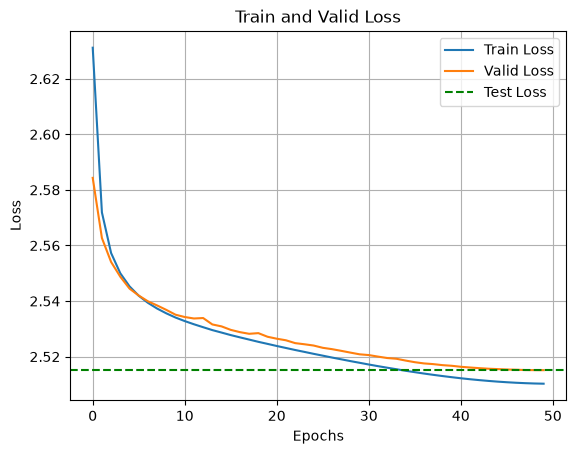

In [4]:
print(f"Test loss: {artifacts.test_loss:.4f}")
plot_loss(
    artifacts.history,
    test_loss=artifacts.test_loss,
    save_path=config.data.output_dir / "loss.png",
)

In [5]:
artifacts.model.generate(max_length=12)

'fuk026'